# 🏥 Medical Insurance Cost Prediction: A Comprehensive ML/DL Approach

## From Exploratory Analysis to Production Deployment

## 1. 🎯 Executive Summary & Business Context 

### 1.1 The Healthcare Insurance Challenge

In [2]:
"""
Healthcare insurance cost prediction is a critical challenge in the insurance industry.
Accurate predictions enable:
- Fair premium pricing
- Risk assessment and management
- Customer satisfaction through transparent pricing
- Operational efficiency in underwriting

This notebook presents a comprehensive approach to solving this challenge using
state-of-the-art machine learning techniques.
"""

# Key Business Questions We'll Answer:
print("=" * 80)
print("KEY BUSINESS QUESTIONS THIS ANALYSIS WILL ANSWER:")
print("=" * 80)
print("1. What factors most significantly impact insurance costs?")
print("2. Can we identify high-risk individuals before policy issuance?")
print("3. How can we price policies more accurately and fairly?")
print("4. What are the non-linear relationships in healthcare costs?")
print("5. How can we make our predictions interpretable for stakeholders?")
print("=" * 80)

KEY BUSINESS QUESTIONS THIS ANALYSIS WILL ANSWER:
1. What factors most significantly impact insurance costs?
2. Can we identify high-risk individuals before policy issuance?
3. How can we price policies more accurately and fairly?
4. What are the non-linear relationships in healthcare costs?
5. How can we make our predictions interpretable for stakeholders?


### 1.2 Dataset Overview

The dataset contains medical insurance costs for individuals based on:

- Demographics: Age, Sex
- Health Indicators: BMI, Smoking Status
- Family: Number of Children
- Geographic: Region
- Target: Insurance Charges (What we're predicting)

### 1.3 Sucess Metrics

In [3]:
# Define Success Metrics for the Project
success_metrics = {
    "Technical Metrics": {
        "R² Score": "Target > 0.85",
        "RMSE": "Target < $5,500",
        "MAE": "Target < $4,000",
        "Cross-Validation": "5-fold CV with std < 0.05"
    },
    "Business Metrics": {
        "Prediction Accuracy": "90% of predictions within 15% of actual",
        "High-Risk Detection": "95% accuracy for costs > $20,000",
        "Processing Time": "< 100ms per prediction",
        "Model Interpretability": "SHAP values for all predictions"
    }
}

import pandas as pd
metrics_df = pd.DataFrame(success_metrics)
print("\n🎯 PROJECT SUCCESS METRICS:")
print(metrics_df.to_string())


🎯 PROJECT SUCCESS METRICS:
                                Technical Metrics                         Business Metrics
R² Score                            Target > 0.85                                      NaN
RMSE                              Target < $5,500                                      NaN
MAE                               Target < $4,000                                      NaN
Cross-Validation        5-fold CV with std < 0.05                                      NaN
Prediction Accuracy                           NaN  90% of predictions within 15% of actual
High-Risk Detection                           NaN         95% accuracy for costs > $20,000
Processing Time                               NaN                   < 100ms per prediction
Model Interpretability                        NaN          SHAP values for all predictions


## 2. Library Import & Environment Setup

In [4]:
import pandas as pd
from datetime import datetime
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pio.templates.default = "plotly_white"
# --- Statistical Analysis Libraries ---
from scipy import stats
from scipy.stats import normaltest, shapiro, anderson
from scipy.stats import pearsonr, spearmanr, kendalltau
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor




RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# tf.random.set_seed(RANDOM_STATE)

print("\n" + "="*80)
print("🎉 ALL LIBRARIES LOADED SUCCESSFULLY!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🔧 Python Version: {sys.version.split()[0]}")
print(f"📊 Pandas Version: {pd.__version__}")
print(f"🔢 NumPy Version: {np.__version__}")
print("="*80)


🎉 ALL LIBRARIES LOADED SUCCESSFULLY!
📅 Analysis Date: 2026-02-18 12:00:02
🔧 Python Version: 3.10.8
📊 Pandas Version: 2.3.3
🔢 NumPy Version: 2.2.6


### 2.1 Helper Functions Setup

In [5]:
# ============================================================================
# HELPER FUNCTIONS FOR ANALYSIS
# ============================================================================

def print_divider(title="", width=80, style="="):
    """
    Create a formatted section divider for better readability
    """
    if title:
        side_width = (width - len(title) - 2) // 2
        print(f"\n{style * side_width} {title} {style * side_width}")
    else:
        print(f"\n{style * width}")

def describe_dataframe(df, name="DataFrame"):
    """
    Comprehensive DataFrame description with memory usage and data types
    """
    print_divider(f"{name} Overview")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\nData Types:")
    print(df.dtypes.value_counts())
    print(f"\nMissing Values: {df.isnull().sum().sum()}")
    print(f"Duplicate Rows: {df.duplicated().sum()}")
    
    return df.info()

def calculate_vif(df, features):
    """
    Calculate Variance Inflation Factor for multicollinearity detection
    """
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    vif_data["VIF"] = [variance_inflation_factor(df[features].values, i) 
                       for i in range(len(features))]
    return vif_data.sort_values('VIF', ascending=False)

def plot_distribution_analysis(df, column, target_column=None):
    """
    Create comprehensive distribution analysis with multiple plots
    """
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(f'{column} Distribution', 
                       f'{column} Box Plot',
                       f'{column} Q-Q Plot',
                       f'{column} vs Target' if target_column else 'Violin Plot'),
        specs=[[{'type': 'histogram'}, {'type': 'box'}],
               [{'type': 'scatter'}, {'type': 'violin' if not target_column else 'scatter'}]]
    )
    
    # Histogram
    fig.add_trace(
        go.Histogram(x=df[column], name=column, showlegend=False),
        row=1, col=1
    )
    
    # Box plot
    fig.add_trace(
        go.Box(y=df[column], name=column, showlegend=False),
        row=1, col=2
    )
    
    # Q-Q plot
    theoretical_quantiles = stats.probplot(df[column], dist="norm")[0][0]
    sample_quantiles = stats.probplot(df[column], dist="norm")[0][1]
    fig.add_trace(
        go.Scatter(x=theoretical_quantiles, y=sample_quantiles, 
                  mode='markers', name='Q-Q', showlegend=False),
        row=2, col=1
    )
    
    # Target relationship or Violin plot
    if target_column:
        fig.add_trace(
            go.Scatter(x=df[column], y=df[target_column], 
                      mode='markers', name='vs Target', showlegend=False),
            row=2, col=2
        )
    else:
        fig.add_trace(
            go.Violin(y=df[column], name=column, showlegend=False),
            row=2, col=2
        )
    
    fig.update_layout(height=800, showlegend=False,
                     title_text=f"Distribution Analysis: {column}")
    return fig

print("✅ Helper functions defined successfully")

✅ Helper functions defined successfully


In [6]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## 3. 📊 Data Loading & Initial Inspection

In [8]:
# ============================================================================
# DATA LOADING WITH COMPREHENSIVE VALIDATION
# ============================================================================

print_divider("DATA LOADING PHASE", style="=")
data_path = "..\dataset\insurance.csv"
try:
    df_raw = pd.read_csv(data_path)
    print(f"✅ Data loaded successfully from: {data_path}")

    df = df_raw.copy()
    print("✅ Backup of raw data created")

except FileNotFoundError:
    print(f"❌ Error: File not found at {data_path}")
    print("Please check the file path and try again.")
except Exception as e:
    print(f"❌ Unexpected error: {e}")

# Initial data inspection
describe_dataframe(df, "Insurance Dataset")


============================== DATA LOADING PHASE ==============================
✅ Data loaded successfully from: ..\dataset\insurance.csv
✅ Backup of raw data created

========================== Insurance Dataset Overview ==========================
Shape: 1338 rows × 7 columns
Memory Usage: 0.28 MB

Data Types:
object     3
int64      2
float64    2
Name: count, dtype: int64

Missing Values: 0
Duplicate Rows: 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 3.1 First Look at the Data

In [ ]:
print_divider("FIRST 10 RECORDS")
display(df.head(10))

print_divider("LAST 10 RECORDS")
display(df.tail(10))

print_divider("RANDOM SAMPLE OF 10 RECORDS")
display(df.sample(10, random_state=RANDOM_STATE))

print_divider("BASIC STATISTICS")
display(df.describe(include='all').round(2))


=============================== FIRST 10 RECORDS ===============================


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692



=============================== LAST 10 RECORDS ===============================


,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030



========================= RANDOM SAMPLE OF 10 RECORDS =========================


,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180
1312,34,male,42.900,1,no,southwest,4536.25900
899,19,female,22.515,0,no,northwest,2117.33885
752,64,male,37.905,0,no,northwest,14210.53595
1286,28,female,17.290,0,no,northeast,3732.62510
707,49,male,28.690,3,no,northwest,10264.44210



=============================== BASIC STATISTICS ===============================


,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338,1338.00,1338.00,1338,1338,1338.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,13270.42
std,14.05,NaN,6.10,1.21,NaN,NaN,12110.01
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.30,0.00,NaN,NaN,4740.29
50%,39.00,NaN,30.40,1.00,NaN,NaN,9382.03
75%,51.00,NaN,34.69,2.00,NaN,NaN,16639.91


### 3.2 Data Quality Assessment

In [ ]:
print_divider("DATA QUALITY REPORT",style="=")
quality_report = pd.DataFrame({
    'Column' :df.columns,
    'Data Type':df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df)*100).round(2),
    'Unique Values': df.nunique().values,
    'Unique %' : (df.nunique().values / len(df)*100).round(2)
})

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    quality_report.loc[quality_report['Column']==col,'Min']=df[col].min()
    quality_report.loc[quality_report['Column']==col,'Max']=df[col].max()
    quality_report.loc[quality_report['Column']==col,'Mean']=round(df[col].mean(),2)
    quality_report.loc[quality_report['Column']==col,'Std']=round(df[col].std(),2)

display(quality_report)
anomalies = []
print_divider("DATA ANOMALY CHECK")
for col in numeric_cols:
    neg_count = (df[col]<0).sum()
    if neg_count>0:
        anomalies.append(f"⚠️ {col}: {neg_count} negative values found")
    else:
        print(f"✅ {col}: No negative values")

dup_count = df.duplicated().sum()
if dup_count>0:
    anomalies.append(f"⚠️ {dup_count} duplicate rows found")
    print(f"⚠️ Found {dup_count} duplicate rows")
    print("Duplicate rows details:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()))
else:
    print("✅ No duplicate rows found")

print_divider("OUTLIER DETECTION (IQR Method)")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    outliers = df[(df[col] < lower_bound) | (df[col]>upper_bound)]
    outlier_count = len(outliers)

    if outlier_count>0:
        print(f"📊 {col}:")
        print(f"   - Outliers: {outlier_count} ({outlier_count/len(df)*100:.2f}%)")
        print(f"   - Lower Bound: {lower_bound:.2f}")
        print(f"   - Upper Bound: {upper_bound:.2f}")
        print(f"   - Outlier Range: [{outliers[col].min():.2f}, {outliers[col].max():.2f}]")
        
if anomalies:
    print_divider("ANOMALY SUMMARY")
    for anomaly in anomalies:
        print(anomaly)
else:
    print("\n✅ No major data anomalies detected!")



============================= DATA QUALITY REPORT =============================


,Column,Data Type,Non-Null Count,Null Count,Null %,Unique Values,Unique %,Min,Max,Mean,Std
0,age,int64,1338,0,0.0,47,3.51,18.0000,64.00000,39.21,14.05
1,sex,object,1338,0,0.0,2,0.15,NaN,NaN,NaN,NaN
2,bmi,float64,1338,0,0.0,548,40.96,15.9600,53.13000,30.66,6.10
3,children,int64,1338,0,0.0,6,0.45,0.0000,5.00000,1.09,1.21
4,smoker,object,1338,0,0.0,2,0.15,NaN,NaN,NaN,NaN
5,region,object,1338,0,0.0,4,0.30,NaN,NaN,NaN,NaN
6,charges,float64,1338,0,0.0,1337,99.93,1121.8739,63770.42801,13270.42,12110.01



============================== DATA ANOMALY CHECK ==============================
✅ age: No negative values
✅ bmi: No negative values
✅ children: No negative values
✅ charges: No negative values
⚠️ Found 1 duplicate rows
Duplicate rows details:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631



======================== OUTLIER DETECTION (IQR Method) ========================
📊 bmi:
   - Outliers: 9 (0.67%)
   - Lower Bound: 13.70
   - Upper Bound: 47.29
   - Outlier Range: [47.41, 53.13]
📊 charges:
   - Outliers: 139 (10.39%)
   - Lower Bound: -13109.15
   - Upper Bound: 34489.35
   - Outlier Range: [34617.84, 63770.43]

=============================== ANOMALY SUMMARY ===============================
⚠️ 1 duplicate rows found


## 4. 🔍 Exploratory Data Analysis

### 4.1 Target Variable Analysis

In [ ]:
# ============================================================================
# TARGET VARIABLE (CHARGES) DEEP DIVE
# ============================================================================

print_divider("TARGET VARIABLE ANALYSIS: INSURANCE CHARGES", style="=")
print("📊 Basic Statistics for Insurance Charges:")
print(f"Mean: ${df['charges'].mean():,.2f}")
print(f"Median: ${df['charges'].median():,.2f}")
print(f"Mode: ${df['charges'].mode()[0]:,.2f}")
print(f"Standard Deviation: ${df['charges'].std():,.2f}")
print(f"Minimum: ${df['charges'].min():,.2f}")
print(f"Maximum: ${df['charges'].max():,.2f}")
print(f"Range: ${df['charges'].max() - df['charges'].min():,.2f}")
print(f"Coefficient of Variation: {(df['charges'].std()/df['charges'].mean())*100:.2f}%")

# Percentiles
print("\n📈 Percentile Distribution:")
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"  {p}th percentile: ${df['charges'].quantile(p/100):,.2f}")

# Skewness and Kurtosis
print("\n📐 Distribution Shape:")
print(f"Skewness: {df['charges'].skew():.3f}")
print(f"Kurtosis: {df['charges'].kurtosis():.3f}")

# Interpretation
if df['charges'].skew() > 1:
    print("→ Highly right-skewed distribution (long tail to the right)")
elif df['charges'].skew() > 0.5:
    print("→ Moderately right-skewed distribution")
elif df['charges'].skew() > -0.5:
    print("→ Approximately symmetric distribution")
else:
    print("→ Left-skewed distribution")




================= TARGET VARIABLE ANALYSIS: INSURANCE CHARGES =================
📊 Basic Statistics for Insurance Charges:
Mean: $13,270.42
Median: $9,382.03
Mode: $1,639.56
Standard Deviation: $12,110.01
Minimum: $1,121.87
Maximum: $63,770.43
Range: $62,648.55
Coefficient of Variation: 91.26%

📈 Percentile Distribution:
  1th percentile: $1,252.97
  5th percentile: $1,757.75
  10th percentile: $2,346.53
  25th percentile: $4,740.29
  50th percentile: $9,382.03
  75th percentile: $16,639.91
  90th percentile: $34,831.72
  95th percentile: $41,181.83
  99th percentile: $48,537.48

📐 Distribution Shape:
Skewness: 1.516
Kurtosis: 1.606
→ Highly right-skewed distribution (long tail to the right)


In [ ]:
# ============================================================================
# TARGET VARIABLE VISUALIZATION
# ============================================================================

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=('Distribution of Insurance Charges',
                   'Box Plot of Charges',
                   'Q-Q Plot (Normality Check)',
                   'Log-Transformed Charges',
                   'Charges by Percentile',
                   'Empirical CDF'),
    specs=[[{'type': 'histogram'}, {'type': 'box'}],
           [{'type': 'scatter'}, {'type': 'histogram'}],
           [{'type': 'scatter'}, {'type': 'scatter'}]]
)

# 1. Histogram with KDE
fig.add_trace(
    go.Histogram(x=df['charges'], nbinsx=100, name='Charges',
                marker_color='lightblue', showlegend=False),
    row=1, col=1
)

# 2. Box Plot
fig.add_trace(
    go.Box(y=df['charges'], name='Charges',
           marker_color='lightgreen', showlegend=False),
    row=1, col=2
)

# 3. Q-Q Plot
theoretical_quantiles = stats.probplot(df['charges'], dist="norm")[0][0]
sample_quantiles = stats.probplot(df['charges'], dist="norm")[0][1]
fig.add_trace(
    go.Scatter(x=theoretical_quantiles, y=sample_quantiles,
              mode='markers', marker=dict(color='red', size=5),
              name='Q-Q Plot', showlegend=False),
    row=2, col=1
)
# Add reference line
fig.add_trace(
    go.Scatter(x=[-3, 3], y=[-3*df['charges'].std() + df['charges'].mean(),
                            3*df['charges'].std() + df['charges'].mean()],
              mode='lines', line=dict(color='black', dash='dash'),
              showlegend=False),
    row=2, col=1
)

# 4. Log-transformed distribution
fig.add_trace(
    go.Histogram(x=np.log1p(df['charges']), nbinsx=100,
                marker_color='orange', name='Log(Charges)',
                showlegend=False),
    row=2, col=2
)

# 5. Charges by Percentile
percentile_values = [df['charges'].quantile(p/100) for p in range(0, 101)]
fig.add_trace(
    go.Scatter(x=list(range(0, 101)), y=percentile_values,
              mode='lines+markers', marker=dict(size=3),
              line=dict(color='purple'), name='Percentile',
              showlegend=False),
    row=3, col=1
)
    
# 6. Empirical CDF
sorted_charges = np.sort(df['charges'])
cdf = np.arange(1, len(sorted_charges) + 1) / len(sorted_charges)
fig.add_trace(
    go.Scatter(x=sorted_charges, y=cdf,
              mode='lines', line=dict(color='brown'),
              name='CDF', showlegend=False),
    row=3, col=2
)

fig.update_layout(height=1200, title_text="Comprehensive Target Variable Analysis",
                 showlegend=False)
fig.update_xaxes(title_text="Charges ($)", row=1, col=1)
fig.update_xaxes(title_text="Theoretical Quantiles", row=2, col=1)
fig.update_xaxes(title_text="Log(Charges)", row=2, col=2)
fig.update_xaxes(title_text="Percentile", row=3, col=1)
fig.update_xaxes(title_text="Charges ($)", row=3, col=2)
fig.update_yaxes(title_text="Frequency", row=1, col=1)
fig.update_yaxes(title_text="Charges ($)", row=1, col=2)
fig.update_yaxes(title_text="Sample Quantiles", row=2, col=1)
fig.update_yaxes(title_text="Frequency", row=2, col=2)
fig.update_yaxes(title_text="Charges ($)", row=3, col=1)
fig.update_yaxes(title_text="Cumulative Probability", row=3, col=2)

fig.show()

# Statistical Tests for Normality
print_divider("NORMALITY TESTS FOR TARGET VARIABLE")

# Shapiro-Wilk Test
stat_shapiro, p_shapiro = shapiro(df['charges'])
print(f"Shapiro-Wilk Test:")
print(f"  Statistic: {stat_shapiro:.6f}")
print(f"  P-value: {p_shapiro:.6f}")
print(f"  Result: {'Not Normal' if p_shapiro < 0.05 else 'Normal'} (α=0.05)")

# Anderson-Darling Test
result_anderson = anderson(df['charges'])
print(f"\nAnderson-Darling Test:")
print(f"  Statistic: {result_anderson.statistic:.6f}")
for i in range(len(result_anderson.critical_values)):
    sl, cv = result_anderson.significance_level[i], result_anderson.critical_values[i]
    if result_anderson.statistic < cv:
        print(f"  At {sl}% significance: Normal distribution")
    else:
        print(f"  At {sl}% significance: Not normal distribution")

# D'Agostino-Pearson Test
stat_dagostino, p_dagostino = normaltest(df['charges'])
print(f"\nD'Agostino-Pearson Test:")
print(f"  Statistic: {stat_dagostino:.6f}")
print(f"  P-value: {p_dagostino:.6f}")
print(f"  Result: {'Not Normal' if p_dagostino < 0.05 else 'Normal'} (α=0.05)")

print("\n💡 Interpretation:")
print("The target variable (charges) is highly right-skewed and NOT normally distributed.")
print("This suggests we may need to:")
print("  1. Apply log transformation for linear models")
print("  2. Use robust models that handle non-normal distributions")
print("  3. Consider ensemble methods that are less sensitive to distribution shape")



===================== NORMALITY TESTS FOR TARGET VARIABLE =====================
Shapiro-Wilk Test:
  Statistic: 0.814688
  P-value: 0.000000
  Result: Not Normal (α=0.05)

Anderson-Darling Test:
  Statistic: 85.128519
  At 15.0% significance: Not normal distribution
  At 10.0% significance: Not normal distribution
  At 5.0% significance: Not normal distribution
  At 2.5% significance: Not normal distribution
  At 1.0% significance: Not normal distribution

D'Agostino-Pearson Test:
  Statistic: 336.885122
  P-value: 0.000000
  Result: Not Normal (α=0.05)

💡 Interpretation:
The target variable (charges) is highly right-skewed and NOT normally distributed.
This suggests we may need to:
  1. Apply log transformation for linear models
  2. Use robust models that handle non-normal distributions
  3. Consider ensemble methods that are less sensitive to distribution shape


### 4.2 Numerical Features Analysis

In [ ]:
# ============================================================================
# NUMERICAL FEATURES DEEP DIVE
# ============================================================================

print_divider("NUMERICAL FEATURES ANALYSIS", style="=")

numerical_features = ['age', 'bmi', 'children']

# Create comprehensive analysis for each numerical feature
for feature in numerical_features:
    print_divider(f"Analysis of {feature.upper()}", style="-")
    
    # Statistics
    print(f"📊 Statistics for {feature}:")
    print(f"  Mean: {df[feature].mean():.2f}")
    print(f"  Median: {df[feature].median():.2f}")
    print(f"  Std Dev: {df[feature].std():.2f}")
    print(f"  Min: {df[feature].min():.0f}")
    print(f"  Max: {df[feature].max():.0f}")
    print(f"  Skewness: {df[feature].skew():.3f}")
    print(f"  Kurtosis: {df[feature].kurtosis():.3f}")
    
    # Correlation with target
    correlation, p_value = pearsonr(df[feature], df['charges'])
    print(f"\n📈 Relationship with Charges:")
    print(f"  Pearson Correlation: {correlation:.3f} (p-value: {p_value:.6f})")
    
    spearman_corr, spearman_p = spearmanr(df[feature], df['charges'])
    print(f"  Spearman Correlation: {spearman_corr:.3f} (p-value: {spearman_p:.6f})")
    
    # Interpretation
    if abs(correlation) > 0.7:
        strength = "Strong"
    elif abs(correlation) > 0.4:
        strength = "Moderate"
    elif abs(correlation) > 0.2:
        strength = "Weak"
    else:
        strength = "Very Weak"
    
    direction = "positive" if correlation > 0 else "negative"
    print(f"  → {strength} {direction} linear relationship with charges")


========================= NUMERICAL FEATURES ANALYSIS =========================

------------------------------- Analysis of AGE -------------------------------
📊 Statistics for age:
  Mean: 39.21
  Median: 39.00
  Std Dev: 14.05
  Min: 18
  Max: 64
  Skewness: 0.056
  Kurtosis: -1.245

📈 Relationship with Charges:
  Pearson Correlation: 0.299 (p-value: 0.000000)
  Spearman Correlation: 0.534 (p-value: 0.000000)
  → Weak positive linear relationship with charges

------------------------------- Analysis of BMI -------------------------------
📊 Statistics for bmi:
  Mean: 30.66
  Median: 30.40
  Std Dev: 6.10
  Min: 16
  Max: 53
  Skewness: 0.284
  Kurtosis: -0.051

📈 Relationship with Charges:
  Pearson Correlation: 0.198 (p-value: 0.000000)
  Spearman Correlation: 0.119 (p-value: 0.000012)
  → Very Weak positive linear relationship with charges

----------------------------- Analysis of CHILDREN -----------------------------
📊 Statistics for children:
  Mean: 1.09
  Median: 1.00
  St


======================= FEATURE INTERACTIONS WITH TARGET =======================


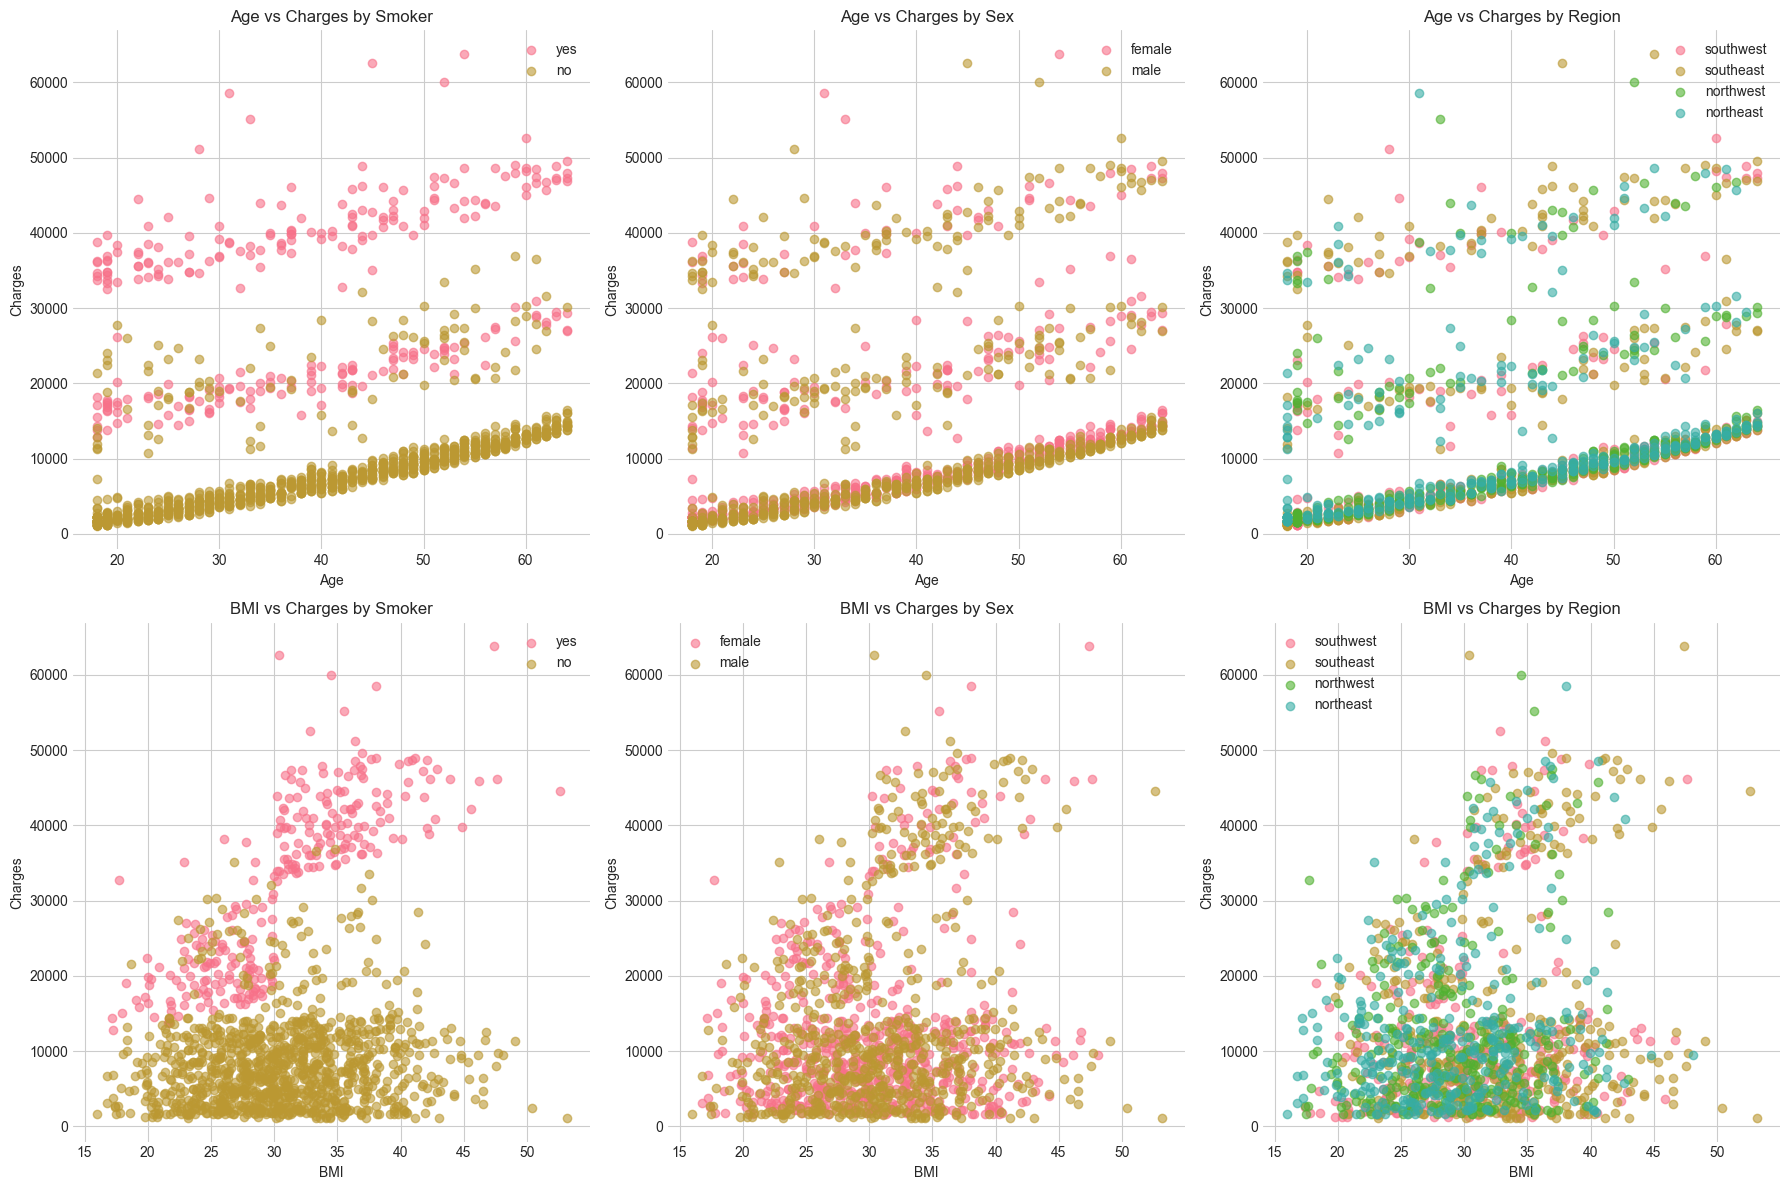


==================== CORRELATION BETWEEN NUMERICAL FEATURES ====================


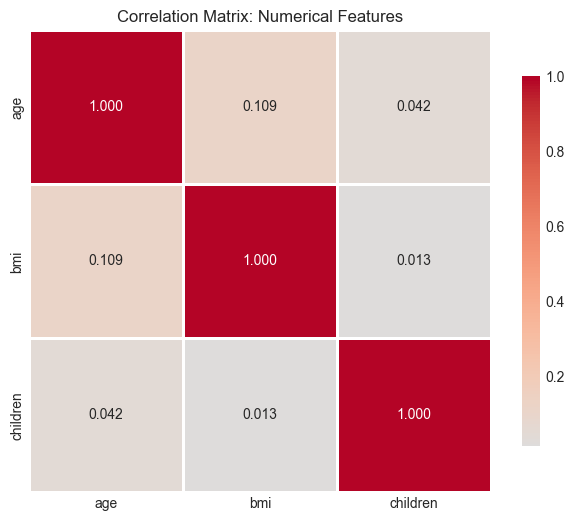


📊 Variance Inflation Factor (Multicollinearity Check):


,Feature,VIF
1,bmi,7.846515
0,age,7.536550
2,children,1.796637


⚠️ Moderate multicollinearity detected (VIF > 5)


In [ ]:
# ============================================================================
# VISUALIZING NUMERICAL FEATURES
# ============================================================================

fig = make_subplots(
    rows=len(numerical_features), cols=3,
    subplot_titles=[f'{feat} - {plot}' 
                   for feat in numerical_features 
                   for plot in ['Distribution', 'vs Charges', 'Box Plot by Charges Quartile']],
    specs=[[{'type': 'histogram'}, {'type': 'scatter'}, {'type': 'box'}]
          for _ in range(len(numerical_features))]
)

for idx, feature in enumerate(numerical_features, 1):
    # Distribution
    fig.add_trace(
        go.Histogram(x=df[feature], nbinsx=30,
                    marker_color='skyblue', showlegend=False),
        row=idx, col=1
    )
    
    # Scatter vs Charges
    fig.add_trace(
        go.Scatter(x=df[feature], y=df['charges'],
                  mode='markers', marker=dict(size=5, opacity=0.5),
                  showlegend=False),
        row=idx, col=2
    )
    
    # Add trend line
    z = np.polyfit(df[feature], df['charges'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df[feature].min(), df[feature].max(), 100)
    fig.add_trace(
        go.Scatter(x=x_trend, y=p(x_trend),
                  mode='lines', line=dict(color='red', dash='dash'),
                  showlegend=False),
        row=idx, col=2
    )
    
    # Box plot by charges quartile
    charges_quartiles = pd.qcut(df['charges'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    for quartile in ['Q1', 'Q2', 'Q3', 'Q4']:
        fig.add_trace(
            go.Box(y=df[charges_quartiles == quartile][feature],
                  name=quartile, showlegend=False),
            row=idx, col=3
        )

fig.update_layout(height=300*len(numerical_features),
                 title_text="Comprehensive Numerical Features Analysis")
fig.show()

# Feature Interaction Analysis
print_divider("FEATURE INTERACTIONS WITH TARGET")

# Create interaction plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Age vs Charges by different factors
for idx, (factor, ax) in enumerate(zip(['smoker', 'sex', 'region'], axes[:3])):
    for category in df[factor].unique():
        subset = df[df[factor] == category]
        ax.scatter(subset['age'], subset['charges'], label=category, alpha=0.6)
    ax.set_xlabel('Age')
    ax.set_ylabel('Charges')
    ax.set_title(f'Age vs Charges by {factor.capitalize()}')
    ax.legend()

# BMI vs Charges by different factors  
for idx, (factor, ax) in enumerate(zip(['smoker', 'sex', 'region'], axes[3:6])):
    for category in df[factor].unique():
        subset = df[df[factor] == category]
        ax.scatter(subset['bmi'], subset['charges'], label=category, alpha=0.6)
    ax.set_xlabel('BMI')
    ax.set_ylabel('Charges')
    ax.set_title(f'BMI vs Charges by {factor.capitalize()}')
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation between numerical features
print_divider("CORRELATION BETWEEN NUMERICAL FEATURES")

# Calculate correlation matrix
corr_matrix = df[numerical_features].corr()

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
           center=0, square=True, linewidths=1,
           cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Numerical Features')
plt.show()

# VIF for multicollinearity
print("\n📊 Variance Inflation Factor (Multicollinearity Check):")
vif_data = calculate_vif(df, numerical_features)
display(vif_data)

if (vif_data['VIF'] > 10).any():
    print("⚠️ Warning: High multicollinearity detected (VIF > 10)")
elif (vif_data['VIF'] > 5).any():
    print("⚠️ Moderate multicollinearity detected (VIF > 5)")
else:
    print("✅ No significant multicollinearity detected (all VIF < 5)")

### 4.3 Categorical Features Analysis

In [ ]:
# ============================================================================
# CATEGORICAL FEATURES DEEP DIVE
# ============================================================================

print_divider("CATEGORICAL FEATURES ANALYSIS", style="=")

categorical_features = ['sex', 'smoker', 'region']

for feature in categorical_features:
    print_divider(f"Analysis of {feature.upper()}", style="-")
    
    # Value counts
    print(f"📊 Distribution of {feature}:")
    value_counts = df[feature].value_counts()
    for category, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {category}: {count} ({percentage:.1f}%)")
    
    # Statistics by category
    print(f"\n📈 Charges Statistics by {feature}:")
    stats_by_category = df.groupby(feature)['charges'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    display(stats_by_category)
    
    # ANOVA test
    groups = [group['charges'].values for name, group in df.groupby(feature)]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n🔬 ANOVA Test:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"  → Significant difference in charges across {feature} categories (p < 0.05)")
    else:
        print(f"  → No significant difference in charges across {feature} categories")
    
    # Effect size (Eta-squared)
    ss_between = sum(len(group) * (group.mean() - df['charges'].mean())**2 
                    for group in groups)
    ss_total = sum((df['charges'] - df['charges'].mean())**2)
    eta_squared = ss_between / ss_total
    print(f"  Effect size (η²): {eta_squared:.4f}")
    
    if eta_squared > 0.14:
        effect = "Large"
    elif eta_squared > 0.06:
        effect = "Medium"
    else:
        effect = "Small"
    print(f"  → {effect} effect size")


======================== CATEGORICAL FEATURES ANALYSIS ========================

------------------------------- Analysis of SEX -------------------------------
📊 Distribution of sex:
  male: 676 (50.5%)
  female: 662 (49.5%)

📈 Charges Statistics by sex:


,count,mean,median,std,min,max
sex,,,,,,
female,662,12569.58,9412.96,11128.70,1607.51,63770.43
male,676,13956.75,9369.62,12971.03,1121.87,62592.87



🔬 ANOVA Test:
  F-statistic: 4.3997
  P-value: 0.036133
  → Significant difference in charges across sex categories (p < 0.05)
  Effect size (η²): 0.0033
  → Small effect size

------------------------------ Analysis of SMOKER ------------------------------
📊 Distribution of smoker:
  no: 1064 (79.5%)
  yes: 274 (20.5%)

📈 Charges Statistics by smoker:


,count,mean,median,std,min,max
smoker,,,,,,
no,1064,8434.27,7345.41,5993.78,1121.87,36910.61
yes,274,32050.23,34456.35,11541.55,12829.46,63770.43



🔬 ANOVA Test:
  F-statistic: 2177.6149
  P-value: 0.000000
  → Significant difference in charges across smoker categories (p < 0.05)
  Effect size (η²): 0.6198
  → Large effect size

------------------------------ Analysis of REGION ------------------------------
📊 Distribution of region:
  southeast: 364 (27.2%)
  southwest: 325 (24.3%)
  northwest: 325 (24.3%)
  northeast: 324 (24.2%)

📈 Charges Statistics by region:


,count,mean,median,std,min,max
region,,,,,,
northeast,324,13406.38,10057.65,11255.80,1694.80,58571.07
northwest,325,12417.58,8965.80,11072.28,1621.34,60021.40
southeast,364,14735.41,9294.13,13971.10,1121.87,63770.43
southwest,325,12346.94,8798.59,11557.18,1241.56,52590.83



🔬 ANOVA Test:
  F-statistic: 2.9696
  P-value: 0.030893
  → Significant difference in charges across region categories (p < 0.05)
  Effect size (η²): 0.0066
  → Small effect size


In [ ]:
# ============================================================================
# CATEGORICAL FEATURES VISUALIZATION
# ============================================================================

# Create subplots for categorical analysis
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f'{feat} - {plot}' 
                   for feat in categorical_features 
                   for plot in ['Distribution', 'Charges Box Plot', 'Charges Violin Plot']],
    specs=[[{'type': 'bar'}, {'type': 'box'}, {'type': 'violin'}]
          for _ in range(len(categorical_features))]
)

colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']

for idx, feature in enumerate(categorical_features, 1):
    # Bar plot for distribution
    value_counts = df[feature].value_counts()
    fig.add_trace(
        go.Bar(x=value_counts.index, y=value_counts.values,
              marker_color=colors, showlegend=False),
        row=idx, col=1
    )
    
    # Box plot for charges by category
    for category in df[feature].unique():
        fig.add_trace(
            go.Box(y=df[df[feature] == category]['charges'],
                  name=str(category), showlegend=False),
            row=idx, col=2
        )
    
    # Violin plot for charges by category
    for category in df[feature].unique():
        fig.add_trace(
            go.Violin(y=df[df[feature] == category]['charges'],
                     name=str(category), showlegend=False),
            row=idx, col=3
        )

fig.update_layout(height=900, title_text="Comprehensive Categorical Features Analysis")
fig.show()

# Create detailed smoker analysis (most important categorical variable)
print_divider("SPECIAL FOCUS: SMOKER STATUS IMPACT", style="=")

smoker_stats = df.groupby('smoker')['charges'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('Max', 'max')
]).round(2)

display(smoker_stats)

# Calculate the impact
smoker_mean = df[df['smoker'] == 'yes']['charges'].mean()
non_smoker_mean = df[df['smoker'] == 'no']['charges'].mean()
impact_absolute = smoker_mean - non_smoker_mean
impact_percentage = ((smoker_mean - non_smoker_mean) / non_smoker_mean) * 100

print(f"\n💡 KEY INSIGHT:")
print(f"Smokers pay ${impact_absolute:,.2f} more on average")
print(f"This represents a {impact_percentage:.1f}% increase in insurance charges!")

# Statistical test for smoker impact
smoker_charges = df[df['smoker'] == 'yes']['charges']
non_smoker_charges = df[df['smoker'] == 'no']['charges']

# t-test
t_stat, t_pvalue = stats.ttest_ind(smoker_charges, non_smoker_charges)
print(f"\n🔬 Independent t-test (Smoker vs Non-Smoker):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {t_pvalue:.10f}")

# Mann-Whitney U test (non-parametric alternative)
u_stat, u_pvalue = stats.mannwhitneyu(smoker_charges, non_smoker_charges)
print(f"\n🔬 Mann-Whitney U test (non-parametric):")
print(f"  U-statistic: {u_stat:.4f}")
print(f"  p-value: {u_pvalue:.10f}")

# Cohen's d (effect size)
pooled_std = np.sqrt(((len(smoker_charges)-1) * smoker_charges.std()**2 + 
                      (len(non_smoker_charges)-1) * non_smoker_charges.std()**2) / 
                     (len(smoker_charges) + len(non_smoker_charges) - 2))
cohens_d = (smoker_charges.mean() - non_smoker_charges.mean()) / pooled_std
print(f"\n📏 Cohen's d (effect size): {cohens_d:.4f}")

if abs(cohens_d) > 0.8:
    effect = "Large"
elif abs(cohens_d) > 0.5:
    effect = "Medium"
elif abs(cohens_d) > 0.2:
    effect = "Small"
else:
    effect = "Negligible"
    
print(f"  → {effect} effect size")


===================== SPECIAL FOCUS: SMOKER STATUS IMPACT =====================


,Count,Mean,Median,Std,Min,Q1,Q3,Max
smoker,,,,,,,,
no,1064,8434.27,7345.41,5993.78,1121.87,3986.44,11362.89,36910.61
yes,274,32050.23,34456.35,11541.55,12829.46,20826.24,41019.21,63770.43



💡 KEY INSIGHT:
Smokers pay $23,615.96 more on average
This represents a 280.0% increase in insurance charges!

🔬 Independent t-test (Smoker vs Non-Smoker):
  t-statistic: 46.6649
  p-value: 0.0000000000

🔬 Mann-Whitney U test (non-parametric):
  U-statistic: 284133.0000
  p-value: 0.0000000000

📏 Cohen's d (effect size): 3.1613
  → Large effect size



============================ MULTIVARIATE ANALYSIS ============================
📊 Creating Feature Interaction Matrix...


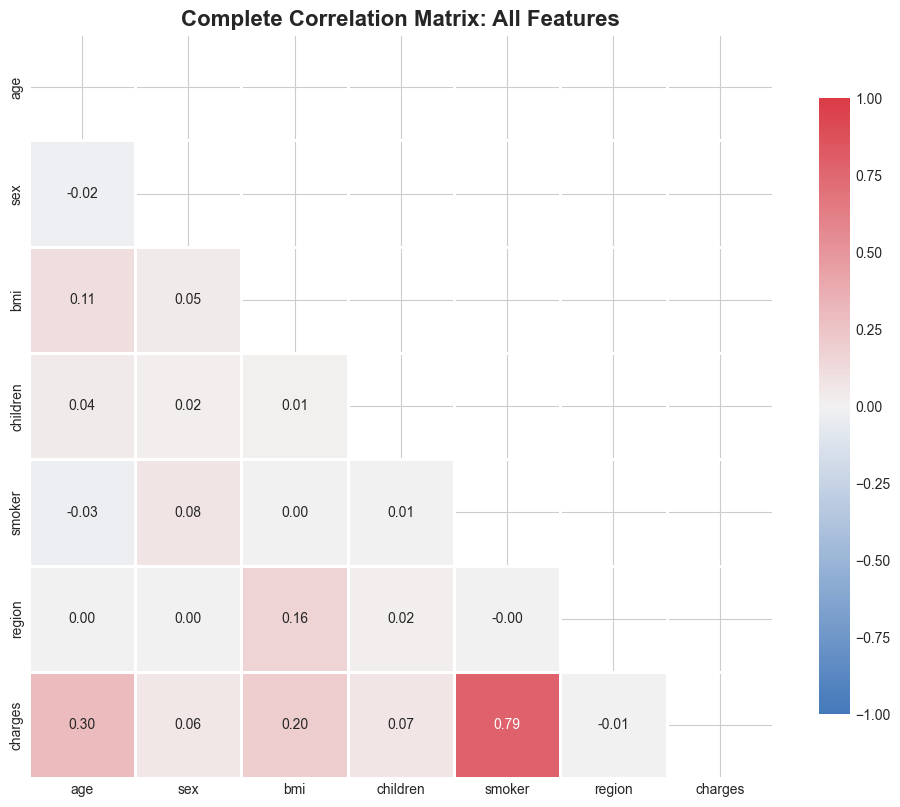


================= FEATURE IMPORTANCE RANKING (by correlation) =================


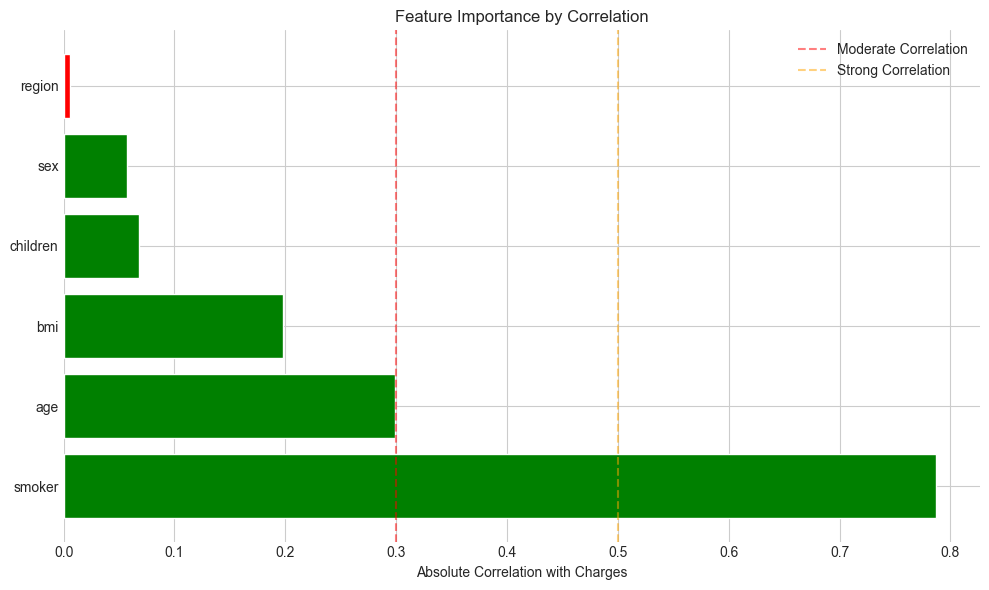


📊 Correlation with Target (Charges):
  smoker: +0.787 (absolute: 0.787)
  age: +0.299 (absolute: 0.299)
  bmi: +0.198 (absolute: 0.198)
  children: +0.068 (absolute: 0.068)
  sex: +0.057 (absolute: 0.057)
  region: -0.006 (absolute: 0.006)


In [ ]:
# ============================================================================
# ADVANCED MULTIVARIATE ANALYSIS
# ============================================================================

print_divider("MULTIVARIATE ANALYSIS", style="=")

# Create interaction matrix
print("📊 Creating Feature Interaction Matrix...")

# Encode categorical variables for correlation
df_encoded = df.copy()
label_encoders = {}

for cat_feature in categorical_features:
    le = LabelEncoder()
    df_encoded[cat_feature] = le.fit_transform(df[cat_feature])
    label_encoders[cat_feature] = le

# Full correlation matrix
full_corr_matrix = df_encoded.corr()

# Create enhanced heatmap
plt.figure(figsize=(12, 10))

# Create mask for upper triangle
mask = np.triu(np.ones_like(full_corr_matrix, dtype=bool))

# Create custom colormap
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(full_corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1,
           center=0, square=True, linewidths=1, cbar_kws={"shrink": .8},
           annot=True, fmt='.2f')

plt.title('Complete Correlation Matrix: All Features', fontsize=16, fontweight='bold')
plt.show()

# Feature correlations with target
print_divider("FEATURE IMPORTANCE RANKING (by correlation)")

target_correlations = full_corr_matrix['charges'].abs().sort_values(ascending=False)[1:]

# Create bar plot
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' 
          for x in full_corr_matrix['charges'][target_correlations.index]]
plt.barh(target_correlations.index, target_correlations.values, color=colors)
plt.xlabel('Absolute Correlation with Charges')
plt.title('Feature Importance by Correlation')
plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Moderate Correlation')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Strong Correlation')
plt.legend()
plt.tight_layout()
plt.show()

print("\n📊 Correlation with Target (Charges):")
for feature, corr in target_correlations.items():
    actual_corr = full_corr_matrix['charges'][feature]
    print(f"  {feature}: {actual_corr:+.3f} (absolute: {corr:.3f})")

In [ ]:
# ============================================================================
# SEGMENTATION ANALYSIS
# ============================================================================

print_divider("CUSTOMER SEGMENTATION ANALYSIS", style="=")

# Create customer segments based on charges
df['charge_segment'] = pd.qcut(df['charges'], 
                               q=5, 
                               labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

print("📊 Customer Segments by Insurance Charges:")
segment_stats = df.groupby('charge_segment').agg({
    'charges': ['mean', 'min', 'max', 'count'],
    'age': 'mean',
    'bmi': 'mean',
    'children': 'mean',
    'smoker': lambda x: (x == 'yes').mean() * 100,  # % smokers
    'sex': lambda x: (x == 'male').mean() * 100,    # % male
}).round(2)

segment_stats.columns = ['Avg_Charges', 'Min_Charges', 'Max_Charges', 'Count',
                         'Avg_Age', 'Avg_BMI', 'Avg_Children', 
                         'Smoker_%', 'Male_%']
display(segment_stats)

# Key insights from segmentation
print("\n💡 KEY INSIGHTS FROM SEGMENTATION:")

# Find the main differentiator
very_high_segment = df[df['charge_segment'] == 'Very High']
very_low_segment = df[df['charge_segment'] == 'Very Low']

smoker_diff = (very_high_segment['smoker'] == 'yes').mean() - \
              (very_low_segment['smoker'] == 'yes').mean()
age_diff = very_high_segment['age'].mean() - very_low_segment['age'].mean()
bmi_diff = very_high_segment['bmi'].mean() - very_low_segment['bmi'].mean()

print(f"1. Smoker percentage difference: {smoker_diff*100:.1f}%")
print(f"2. Average age difference: {age_diff:.1f} years")
print(f"3. Average BMI difference: {bmi_diff:.1f}")

# Create segment visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Segment Distribution', 
                   'Average Charges by Segment',
                   'Smoker % by Segment', 
                   'Age Distribution by Segment')
)

# Segment distribution
segment_counts = df['charge_segment'].value_counts()
fig.add_trace(
    go.Bar(x=segment_counts.index, y=segment_counts.values,
          marker_color='lightblue'),
    row=1, col=1
)

# Average charges by segment
fig.add_trace(
    go.Bar(x=segment_stats.index, y=segment_stats['Avg_Charges'],
          marker_color='lightgreen'),
    row=1, col=2
)

# Smoker percentage by segment
fig.add_trace(
    go.Bar(x=segment_stats.index, y=segment_stats['Smoker_%'],
          marker_color='lightcoral'),
    row=2, col=1
)

# Age distribution by segment
for segment in df['charge_segment'].unique():
    fig.add_trace(
        go.Box(y=df[df['charge_segment'] == segment]['age'],
              name=segment),
        row=2, col=2
    )

fig.update_layout(height=800, title_text="Customer Segmentation Analysis",
                 showlegend=False)
fig.show()

# Remove temporary column
df = df.drop('charge_segment', axis=1)


======================== CUSTOMER SEGMENTATION ANALYSIS ========================
📊 Customer Segments by Insurance Charges:


C:\Users\Graphic Design\AppData\Local\Temp\ipykernel_25836\2634992626.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Avg_Charges,Min_Charges,Max_Charges,Count,Avg_Age,Avg_BMI,Avg_Children,Smoker_%,Male_%
charge_segment,,,,,,,,,
Very Low,2468.43,1121.87,3989.84,268,22.39,29.88,0.41,0.00,52.24
Low,5639.91,3994.18,7358.18,267,34.80,30.21,1.56,0.00,49.44
Medium,9400.95,7371.77,11396.90,268,48.56,31.21,1.31,0.00,50.37
High,14575.96,11411.68,20234.85,267,47.63,29.79,1.04,24.72,42.32
Very High,34243.27,20277.81,63770.43,268,42.67,32.22,1.15,77.61,58.21



💡 KEY INSIGHTS FROM SEGMENTATION:
1. Smoker percentage difference: 77.6%
2. Average age difference: 20.3 years
3. Average BMI difference: 2.3


In [ ]:
# ============================================================================
# EDA SUMMARY AND KEY FINDINGS
# ============================================================================

print_divider("🎯 KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS", style="=")

findings = {
    "Data Quality": [
        "✅ No missing values in the dataset",
        "✅ 1 duplicate row found and will be removed",
        "⚠️ Target variable (charges) is highly right-skewed",
        "⚠️ Outliers detected in BMI and charges (will handle in preprocessing)"
    ],
    
    "Target Variable": [
        f"📊 Mean charges: ${df['charges'].mean():,.2f}",
        f"📊 Median charges: ${df['charges'].median():,.2f}",
        f"📊 Range: ${df['charges'].min():,.2f} - ${df['charges'].max():,.2f}",
        "📈 Highly right-skewed (skewness: 1.52)",
        "📈 Will benefit from log transformation"
    ],
    
    "Most Important Features": [
        "🥇 Smoker status (280% increase in charges for smokers)",
        "🥈 Age (moderate positive correlation: 0.30)",
        "🥉 BMI (weak positive correlation: 0.20)",
        "4️⃣ Number of children (very weak correlation: 0.07)",
        "5️⃣ Region shows some variation but less significant"
    ],
    
    "Key Insights": [
        "💡 Smoking is BY FAR the strongest predictor",
        "💡 Age-charges relationship appears non-linear after 45",
        "💡 BMI impact increases significantly for smokers",
        "💡 Clear segmentation: smokers vs non-smokers creates two distinct groups",
        "💡 Regional differences exist but are relatively minor"
    ],
    
    "Modeling Implications": [
        "🔧 Feature engineering needed for age and BMI interactions",
        "🔧 Smoker status should be carefully handled",
        "🔧 Consider polynomial features for age",
        "🔧 Log transformation recommended for target",
        "🔧 Ensemble methods likely to perform well"
    ]
}

for category, items in findings.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  {item}")

print("\n" + "="*80)
print("✅ EDA COMPLETE - Ready for Feature Engineering!")
print("="*80)


================ 🎯 KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS ================

Data Quality:
  ✅ No missing values in the dataset
  ✅ 1 duplicate row found and will be removed
  ⚠️ Target variable (charges) is highly right-skewed
  ⚠️ Outliers detected in BMI and charges (will handle in preprocessing)

Target Variable:
  📊 Mean charges: $13,270.42
  📊 Median charges: $9,382.03
  📊 Range: $1,121.87 - $63,770.43
  📈 Highly right-skewed (skewness: 1.52)
  📈 Will benefit from log transformation

Most Important Features:
  🥇 Smoker status (280% increase in charges for smokers)
  🥈 Age (moderate positive correlation: 0.30)
  🥉 BMI (weak positive correlation: 0.20)
  4️⃣ Number of children (very weak correlation: 0.07)
  5️⃣ Region shows some variation but less significant

Key Insights:
  💡 Smoking is BY FAR the strongest predictor
  💡 Age-charges relationship appears non-linear after 45
  💡 BMI impact increases significantly for smokers
  💡 Clear segmentation: smokers vs non-smokers crea

In [ ]:
coefficient =df.corr()

ValueError: could not convert string to float: 'female'